### **We use the existing model for glacier mapping**
all the validation scenes are used for validation:    
|model|miou |oa    |fi-score  |precision  |recall  |update_time|    
|-----|-----|-----|------|------|------|-----------|      
|unet ||||||/|     
|deeplabv3+ ||||||      
| |||||||        


In [1]:
import glob
import torch
import numpy as np
import pandas as pd
import rasterio as rio
from notebooks import config
from utils.imgShow import imsShow
from utils.img2patch import img2patch
from utils.metrics import metrics_segm
from model import unet, u2net, u2net_timm


In [2]:
paths_val_scene = config.paths_scene_val
paths_val_truth = config.paths_truth_val
# paths_val_result = sorted(glob.glob('data/result/kang/*'))
paths_val_result = sorted(glob.glob('data/result/u3net_cross_fusion/*'))
print(len(config.paths_scene_val))  


13


In [33]:
## read data
scenes, results, truths = [], [], []
for path_scene, path_result, path_truth in zip(paths_val_scene, paths_val_result,  paths_val_truth):
    with rio.open(path_scene) as scene_rio:
        scene_arr = scene_rio.read()
        scene_arr = scene_arr.transpose((1, 2, 0))   ## (H,W,C)
        scenes.append(scene_arr)
    with rio.open(path_result) as result_rio:
        result_arr = result_rio.read(1)
        results.append(result_arr)
    with rio.open(path_truth) as truth_rio:
        truth_arr = truth_rio.read(1)                ## (H,W)
        profile_truth = truth_rio.profile
        truths.append(truth_arr)


In [38]:
metrics_scenes = {}
for i, (result_arr, truth_arr) in enumerate(zip(results, truths)):
    metrics_sg = metrics_segm(cla_map=result_arr, truth_map=truth_arr, 
                              class_labels=[0, 1], mean_mode=True)
    metrics = {'oa': metrics_sg.oa,
                   'f1_score': metrics_sg.f1_score['labels_mean'],
                   'miou': metrics_sg.iou['labels_mean']}
    metrics_scenes[paths_val_truth[i].split('/')[-1].split('.')[0]] = metrics
len(metrics_scenes)  


13

In [ ]:
df_metrics_scenes = pd.DataFrame.from_dict(metrics_scenes, orient='index')
df_metrics_scenes.loc['mean'] = df_metrics_scenes.mean(axis=0)
# weighted_avg = (df_metrics_scenes[['oa', 'f1_score', 'miou']].mul(df_metrics_scenes['weight'], axis=0).sum())
# df_metrics_scenes.loc['mean_weighted'] = weighted_avg
# df_metrics_scenes  
df_metrics_scenes 


,oa,f1_score,miou
l5_scene_01,0.982784,0.964837,0.933201
l5_scene_06,0.978707,0.952348,0.911218
l5_scene_11,0.993083,0.993023,0.986143
l7_scene_03,0.978331,0.978269,0.957465
l7_scene_08,0.984892,0.983608,0.967784
l7_scene_13,0.991751,0.977561,0.956704
l8_scene_05,0.991567,0.940064,0.892105
l8_scene_10,0.989719,0.985902,0.972299
l9_scene_02,0.997353,0.987721,0.975969
l9_scene_07,0.975227,0.922433,0.862602


scene: l9_scene_07.tif, miou: 0.8626


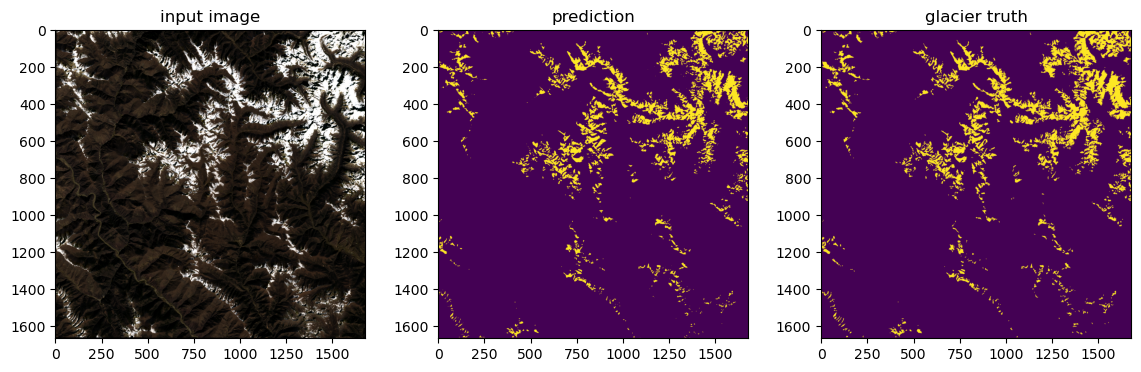

In [19]:
### show the results
i = 9
print(f'scene: {paths_val_scene[i].split("/")[-1]}, miou: {df_metrics_scenes.iloc[i]["miou"]:.4f}')
imsShow([scenes[i], results[i], truths[i]], 
        clip_list=[5, 0, 0], 
        img_name_list = ['input image', 'prediction', 'glacier truth'],
        figsize=(14, 4))
